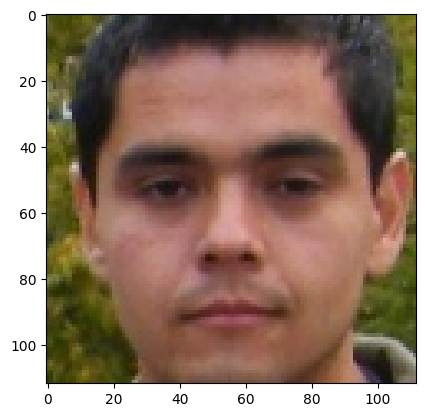

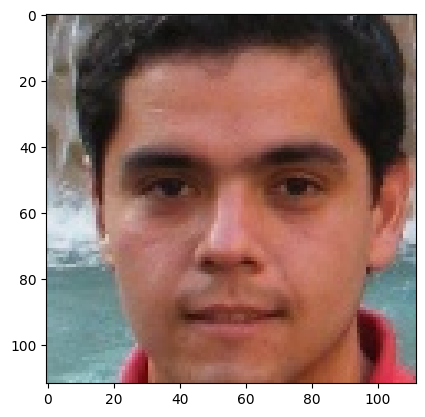

torch.Size([1, 512])
Distance: tensor([0.9036], device='cuda:0', grad_fn=<SumBackward1>)


In [57]:
import torch
from advcloak.model_irse import IR_50
import cv2
import matplotlib.pyplot as plt
import torch.nn.functional as F

device = torch.device("cuda")

model = IR_50((112, 112))
#model.load_state_dict(torch.load("../model_checkpoints/models/surrogate/IR_50-ArcFace-casia/Backbone_IR_50_Epoch_73_Batch_138000_Time_2020-05-07-23-48_checkpoint.pth"))
#model.load_state_dict(torch.load("../model_checkpoints/models/surrogate/IR_50-CosFace-casia/Backbone_IR_50_Epoch_74_Batch_140000_Time_2020-05-27-21-38_checkpoint.pth"))
model.load_state_dict(torch.load("../model_checkpoints/models/surrogate/IR_50-Softmax-casia/Backbone_IR_50_Epoch_94_Batch_180000_Time_2020-03-30-01-55_checkpoint.pth"))
model.eval()
model.to(device)

im1 = cv2.imread("../data/privacy_common/probe/4191_0.jpg")
im2 = cv2.imread("../data/privacy_common/gallery/4191_1.jpg")

im1 = cv2.cvtColor(im1, cv2.COLOR_BGR2RGB)
im2 = cv2.cvtColor(im2, cv2.COLOR_BGR2RGB)

plt.imshow(im1)
plt.show()
plt.imshow(im2)
plt.show()

im1 = (im1 - 127.5) * 2./255
im2 = (im2 - 127.5) * 2./255

im1 = torch.tensor(im1).to(device).permute(2, 0, 1).float().unsqueeze(0)
im2 = torch.tensor(im2).to(device).permute(2, 0, 1).float().unsqueeze(0)
emb1 = model(im1)
emb2 = model(im2)
print(emb1.size())
emb1 = F.normalize(emb1, dim=-1)
emb2 = F.normalize(emb2, dim=-1)

sim = F.cosine_similarity(emb1, emb2)
print("Distance:", sim)

In [1]:
!nvcc --version

nvcc: NVIDIA (R) Cuda compiler driver
Copyright (c) 2005-2025 NVIDIA Corporation
Built on Tue_May_27_02:21:03_PDT_2025
Cuda compilation tools, release 12.9, V12.9.86
Build cuda_12.9.r12.9/compiler.36037853_0


In [1]:
import numpy as np
import torch
import cv2
from blazeface.blazeface import BlazeFace
from facenet_pytorch import MTCNN

%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def plot_detections(img, detections, with_keypoints=True):
    fig, ax = plt.subplots(1, figsize=(10, 10))
    ax.grid(False)
    ax.imshow(img)
    
    if isinstance(detections, torch.Tensor):
        detections = detections.cpu().numpy()

    if detections.ndim == 1:
        detections = np.expand_dims(detections, axis=0)

    print("Found %d faces" % detections.shape[0])
        
    for i in range(detections.shape[0]):
        ymin = detections[i, 0] * img.shape[0]
        xmin = detections[i, 1] * img.shape[1]
        ymax = detections[i, 2] * img.shape[0]
        xmax = detections[i, 3] * img.shape[1]

        rect = patches.Rectangle((xmin, ymin), xmax - xmin, ymax - ymin,
                                 linewidth=1, edgecolor="r", facecolor="none", 
                                 alpha=detections[i, 16])
        ax.add_patch(rect)

        if with_keypoints:
            for k in range(6):
                kp_x = detections[i, 4 + k*2    ] * img.shape[1]
                kp_y = detections[i, 4 + k*2 + 1] * img.shape[0]
                circle = patches.Circle((kp_x, kp_y), radius=0.5, linewidth=1, 
                                        edgecolor="lightskyblue", facecolor="none", 
                                        alpha=detections[i, 16])
                ax.add_patch(circle)
        
    plt.show()

/home/hice1/zyahn3/.conda/envs/Face/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


(177, 156, 3) shape
(1, 5, 2)
[[45.295509338378906 45.58369445800781 112.832275390625
  133.57423400878906]]
MTCNN landmarks are: [[[56.28371047973633 78.51762390136719]
  [84.31082916259766 77.01588439941406]
  [63.45246887207031 93.79310607910156]
  [56.42700958251953 111.8389892578125]
  [82.06541442871094 111.07853698730469]]]
Side lengths differed by: 20.453773498535156
[35 45 122 133]
(88, 87, 3)


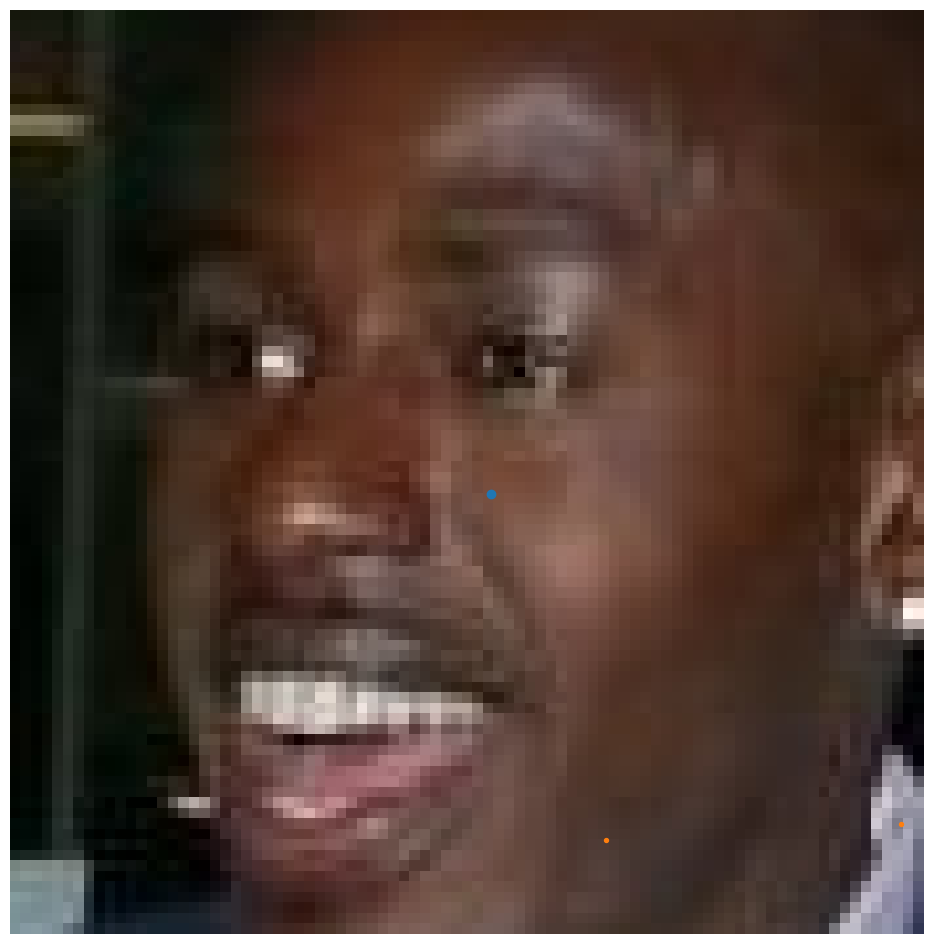

BlazeFace landmarks are: tensor([0.2633, 0.3691, 0.5713, 0.3580, 0.3099, 0.5388, 0.3555, 0.7269, 0.2307,
        0.4333, 0.8764, 0.4268, 0.9726], device='cuda:0')
Right eye is at: 33.70241928100586 47.245849609375
Left eye is at: 73.13016510009766 45.82240676879883


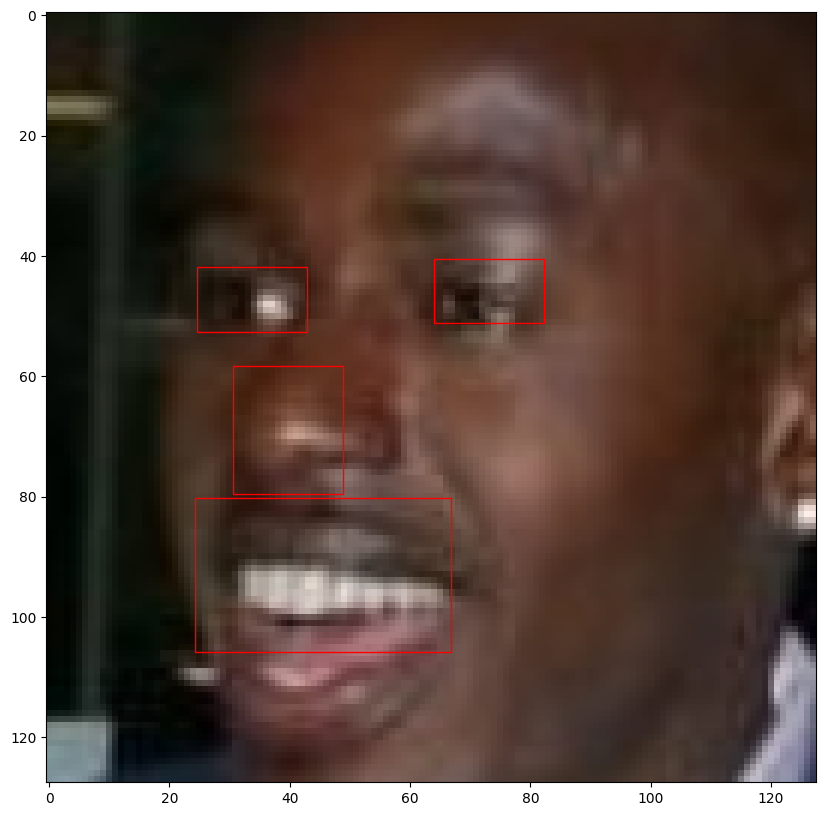

In [3]:
device = torch.device("cuda")
%matplotlib inline

img = cv2.imread("../data/vggface_tiny_flat/n000950_001601.jpg")
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
mtcnn = MTCNN(image_size=112, device=device).to(device).eval()
print(img.shape, "shape")
boxes, probs, landmarks = mtcnn.detect(img, landmarks=True)
print(landmarks.shape)
# boxes = boxes[0]
# landmarks = landmarks[0]

# Visualize
fig, ax = plt.subplots(figsize=(16, 12))
ax.imshow(img)
ax.axis('off')

for box, landmark in zip(boxes, landmarks):
    ax.scatter(*np.meshgrid(box[[0, 2]], box[[1, 3]]))
    ax.scatter(landmark[:, 0], landmark[:, 1], s=8)
fig.show()

print(boxes)
print("MTCNN landmarks are:", landmarks)

boxes = boxes[0]
landmarks = landmarks[0]

#Make boxes square
side_length = max(boxes[3] - boxes[1], boxes[2] - boxes[0])
diff = side_length - min(boxes[3] - boxes[1], boxes[2] - boxes[0])
print("Side lengths differed by:", diff)
add_to_side = int(diff / 2)
if boxes[3] - boxes[1] < boxes[2] - boxes[0]:
    boxes[3] += add_to_side
    boxes[1] -= add_to_side
else:
    boxes[2] += add_to_side
    boxes[0] -= add_to_side
    
# Make sure they don't overflow on the image
for i in range(4):
    boxes[i] = int(boxes[i]) if boxes[i] >= 0.0 else 0
    boxes[2] = boxes[2] if boxes[2] < img.shape[1] else img.shape[1] - 1
    boxes[3] = boxes[3] if boxes[3] < img.shape[0] else img.shape[0] - 1

print(boxes)

# Parse out the values
xmin = int(boxes[0])
ymin = int(boxes[1])
xmax = int(boxes[2])
ymax = int(boxes[3])

crop = img[ymin:ymax, xmin:xmax, :]
print(crop.shape)
plt.imshow(crop)
plt.show()

crop = cv2.resize(crop, (128, 128))

model = BlazeFace().to(device)
model.load_weights("blazeface/blazeface.pth")
model.load_anchors("blazeface/anchors.npy")

EYE_BOX_WIDTH = crop.shape[1] / 7
EYE_BOX_HEIGHT = crop.shape[0] / 12
NOSE_BOX_WIDTH = crop.shape[1] / 7
NOSE_BOX_HEIGHT = crop.shape[0] / 6
MOUTH_BOX_WIDTH = crop.shape[1] / 3
MOUTH_BOX_HEIGHT = crop.shape[0] / 5

dets = model.predict_on_image(crop)
print("BlazeFace landmarks are:", dets[0][4:])
r_eye_x = dets[0][4].cpu().numpy() * crop.shape[1]
r_eye_y = dets[0][5].cpu().numpy() * crop.shape[0]
l_eye_x = dets[0][6].cpu().numpy() * crop.shape[1]
l_eye_y = dets[0][7].cpu().numpy() * crop.shape[0]
nose_x = dets[0][8].cpu().numpy() * crop.shape[1]
nose_y = dets[0][9].cpu().numpy() * crop.shape[0]
mouth_x = dets[0][10].cpu().numpy() * crop.shape[1]
mouth_y = dets[0][11].cpu().numpy() * crop.shape[0]
print("Right eye is at:", r_eye_x, r_eye_y)
print("Left eye is at:", l_eye_x, l_eye_y)
#plot_detections(crop, dets)

fig, ax = plt.subplots(1, figsize=(10, 10))
ax.grid(False)
ax.imshow(crop)
rect = patches.Rectangle((r_eye_x - EYE_BOX_WIDTH / 2, r_eye_y - EYE_BOX_HEIGHT / 2), EYE_BOX_WIDTH, EYE_BOX_HEIGHT, edgecolor='red', facecolor="none")
ax.add_patch(rect)
rect = patches.Rectangle((l_eye_x - EYE_BOX_WIDTH / 2, l_eye_y - EYE_BOX_HEIGHT / 2), EYE_BOX_WIDTH, EYE_BOX_HEIGHT, edgecolor='red', facecolor="none")
ax.add_patch(rect)
rect = patches.Rectangle((nose_x - NOSE_BOX_WIDTH / 2, nose_y - NOSE_BOX_HEIGHT / 2), NOSE_BOX_WIDTH, NOSE_BOX_HEIGHT, edgecolor='red', facecolor="none")
ax.add_patch(rect)
rect = patches.Rectangle((mouth_x - MOUTH_BOX_WIDTH / 2, mouth_y - MOUTH_BOX_HEIGHT / 2), MOUTH_BOX_WIDTH, MOUTH_BOX_HEIGHT, edgecolor='red', facecolor="none")
ax.add_patch(rect)

plt.show()

In [1]:
import warnings
warnings.filterwarnings('ignore')

from facenet_pytorch import MTCNN, InceptionResnetV1
import torch
import cv2
import matplotlib.pyplot as plt
import numpy as np
import argparse
from cloaker import Cloaker
from cloak_functions import pgd_cloak, sgd_cloak, afog_cloak, pgd_cloak_multi, afog_cloak_multi, minmax_cloak, pgd_cloak_sticker
from loss_functions import fawkes_loss, triplet_loss, dssim_loss, lpips_loss, untarget_loss
from dist_functions import cosine_dist, l2_dist
from utils import preprocess_tanh, reverse_tanh, preprocess_divide, reverse_divide
#from insightface.recognition.arcface_torch.backbones import get_model
import matplotlib.pyplot as plt
import os
%matplotlib inline
%load_ext autoreload
%autoreload 2


device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")

# Configure all of the variables
dataset_path="../data/vggface_tiny_flat"
extractor_path=None
batch_size=1
cropped_im_size = 112
target_pool_size = 100
num_cloaked_images = 100
num_dataset_images = 1.0
cloak_save_path = None
verbosity = "none"
extractor_type = "Facenet"
distance_function = "cosine"
norm_function = "divide"
cloak_function = "pgd_cloak"
multi_cloak_function = "pgd_cloak_sticker"
cloak_loss = "triplet"
multi_cloak_loss = "triplet"
cloak_function_iters = 10
multi_cloak_function_iters = 10
cloak_function_step = 2.
cloak_function_max_pert = 4
multi_cloak_function_max_pert = 4
cloak_function_lr = 0.5
cloak_percep_loss = "dssim"
percep_loss_weight = 0.0
mode = "multi"
makeup_mode = None
gen_save_path = "data/gen/notebook"
num_gen_iterations=4
gen_learning_rate=0.001
num_images_to_generate=4

cloak_function_step = cloak_function_step / 255.
cloak_function_max_pert = cloak_function_max_pert / 255.
multi_cloak_function_max_pert = multi_cloak_function_max_pert / 255.

model_shorthands = {
        "ArcFaceR18":"r18",
        "ArcFaceR34":"r34",
        "ArcFaceR50":"r50",
        "ArcFaceR100":"r100",
        "CosFaceR18":"r18",
        "CosFaceR34":"r34",
        "CosFaceR50":"r50",
        "CosFaceR100":"r100",
        }

model_paths = {
        "ArcFaceR18":"model_checkpoints/arcface_r18_ms1mv3.pth",
        "ArcFaceR34":"model_checkpoints/arcface_r34_ms1mv3.pth",
        "ArcFaceR50":"model_checkpoints/arcface_r50_ms1mv3.pth",
        "ArcFaceR100":"model_checkpoints/arcface_r100_ms1mv3.pth",
        "CosFaceR18":"model_checkpoints/cosface_r18_glint360k.pth",
        "CosFaceR34":"model_checkpoints/cosface_r34_glint360k.pth",
        "CosFaceR50":"model_checkpoints/cosface_r50_glint360k.pth",
        "CosFaceR100":"model_checkpoints/cosface_r100_glint360k.pth",
        }

# Note: a function below adds CosFace and ArcFace models to this dictionary
extractors = {
        #"ArcFace":torch_arcface_insightface(device).to(device),
        "Facenet":InceptionResnetV1(pretrained='vggface2').to(device)
    }

cloak_funcs = {
        "pgd_cloak":pgd_cloak,
        "pgd_cloak_multi":pgd_cloak_multi,
        "pgd_cloak_sticker":pgd_cloak_sticker,
        "minmax_cloak": minmax_cloak,
        "sgd_cloak":sgd_cloak,
        "afog_cloak":afog_cloak,
        "afog_cloak_multi":afog_cloak_multi,
        "none":None
    }

cloak_losses = {
        "fawkes":fawkes_loss,
        "triplet":triplet_loss,
        "untarget":untarget_loss,
        "none":None
    }

distance_funcs = {
        "cosine":cosine_dist,
        "l2":l2_dist
    }

norm_funcs = {
        "tanh":preprocess_tanh,
        "divide":preprocess_divide
        }

reverse_norm_funcs = {
        "tanh":reverse_tanh,
        "divide":reverse_divide
        }

percep_losses = {
        "dssim": dssim_loss,
        "lpips": lpips_loss,
        "none": None
        }

# Handle loading in the weights of an insightface model (arcface or cosface)
def load_arcface_cosface_model(model):
    if_model = get_model(model_shorthands[model], fp16=False)
    if_model.load_state_dict(torch.load(model_paths[model], map_location=device))
    if_model.eval().to(device)
    extractors[model] = if_model

# Get the extractor, cloaking optimization function, loss function. If we're using ArcFace or CosFace, normalize accordingly
if "ArcFace" in extractor_type or "CosFace" in extractor_type:
    load_arcface_cosface_model(extractor_type)
    norm_function = preprocess_divide
    reverse_norm_function = reverse_divide

extractor = extractors[extractor_type]
cloak_function = cloak_funcs[cloak_function]
multi_cloak_function = cloak_funcs[multi_cloak_function]
loss_function = cloak_losses[cloak_loss]
multi_loss_function = cloak_losses[multi_cloak_loss]
distance_function = distance_funcs[distance_function]
norm = norm_funcs[norm_function]
reverse_norm = reverse_norm_funcs[norm_function]
percep_loss_function = percep_losses[cloak_percep_loss]


# Get MTCNN for crop and align
mtcnn = MTCNN(image_size=cropped_im_size, device=device).to(device)

print("Extracting with model:", extractor_type)

# Initialize cloaker
cloaker = Cloaker(
        dataset_path=dataset_path, 
        extractor=extractor, 
        cropper=mtcnn, 
        batch_size=batch_size, 
        cropped_im_size=cropped_im_size, 
        target_pool_size=target_pool_size, 
        num_dataset_images=num_dataset_images, 
        device=device, 
        verbosity=verbosity,
        distance_function=distance_function,
        cloak_function=cloak_function,
        multi_cloak_function = multi_cloak_function,
        cloak_loss=loss_function,
        multi_cloak_loss=multi_loss_function,
        cloak_function_iters=cloak_function_iters,
        multi_cloak_function_iters=multi_cloak_function_iters,
        cloak_function_step=cloak_function_step,
        cloak_function_max_pert=cloak_function_max_pert,
        multi_cloak_function_max_pert=multi_cloak_function_max_pert,
        cloak_function_lr=cloak_function_lr,
        loss_func_select=cloak_loss,
        multi_loss_func_select=multi_cloak_loss,
        norm_function = norm,
        reverse_norm_function = reverse_norm,
        percep_loss = percep_loss_function,
        percep_loss_weight = percep_loss_weight,
        mode=mode,
        num_gen_iterations=num_gen_iterations,
        gen_learning_rate=gen_learning_rate,
        num_images_to_generate=num_images_to_generate,
        )

2025-10-03 15:44:27.356198: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-10-03 15:44:27.508245: I tensorflow/core/util/util.cc:169] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-10-03 15:44:27.539634: E tensorflow/stream_executor/cuda/cuda_blas.cc:2981] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-10-03 15:44:28.428251: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Co

Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]
Loading model from: /home/hice1/zyahn3/.conda/envs/Face/lib/python3.10/site-packages/lpips/weights/v0.1/alex.pth
Extracting with model: Facenet
Loading dataset with 500 images.


Loading pipeline components...: 100%|██████████| 6/6 [00:00<00:00, 36.36it/s]
You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .
2025-10-03 15:44:37.611228512 [E:onnxruntime:Default, env.cc:234 ThreadMain] pthread_setaffinity_np failed for thread: 4187946, index: 0, mask: {24, }, error code: 22 error msg: Invalid argument. Specify the number of threads explicitly so the affinity is not set.
2025-

Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: arc2face/models/antelopev2/1k3d68.onnx landmark_3d_68 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}


2025-10-03 15:44:38.232903983 [E:onnxruntime:Default, env.cc:234 ThreadMain] pthread_setaffinity_np failed for thread: 4188011, index: 0, mask: {24, }, error code: 22 error msg: Invalid argument. Specify the number of threads explicitly so the affinity is not set.
2025-10-03 15:44:38.232944668 [E:onnxruntime:Default, env.cc:234 ThreadMain] pthread_setaffinity_np failed for thread: 4188012, index: 1, mask: {48, }, error code: 22 error msg: Invalid argument. Specify the number of threads explicitly so the affinity is not set.
2025-10-03 15:44:38.233004252 [E:onnxruntime:Default, env.cc:234 ThreadMain] pthread_setaffinity_np failed for thread: 4188013, index: 2, mask: {8, }, error code: 22 error msg: Invalid argument. Specify the number of threads explicitly so the affinity is not set.
2025-10-03 15:44:38.245825936 [E:onnxruntime:Default, env.cc:234 ThreadMain] pthread_setaffinity_np failed for thread: 4188014, index: 3, mask: {32, }, error code: 22 error msg: Invalid argument. Specify th

find model: arc2face/models/antelopev2/2d106det.onnx landmark_2d_106 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: arc2face/models/antelopev2/arcface.onnx recognition ['None', 3, 112, 112] 127.5 127.5
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: arc2face/models/antelopev2/genderage.onnx genderage ['None', 3, 96, 96] 0.0 1.0


2025-10-03 15:44:39.362890090 [E:onnxruntime:Default, env.cc:234 ThreadMain] pthread_setaffinity_np failed for thread: 4188138, index: 0, mask: {24, }, error code: 22 error msg: Invalid argument. Specify the number of threads explicitly so the affinity is not set.
2025-10-03 15:44:39.362984822 [E:onnxruntime:Default, env.cc:234 ThreadMain] pthread_setaffinity_np failed for thread: 4188140, index: 2, mask: {8, }, error code: 22 error msg: Invalid argument. Specify the number of threads explicitly so the affinity is not set.
2025-10-03 15:44:39.362981720 [E:onnxruntime:Default, env.cc:234 ThreadMain] pthread_setaffinity_np failed for thread: 4188139, index: 1, mask: {48, }, error code: 22 error msg: Invalid argument. Specify the number of threads explicitly so the affinity is not set.
2025-10-03 15:44:39.364533777 [E:onnxruntime:Default, env.cc:234 ThreadMain] pthread_setaffinity_np failed for thread: 4188147, index: 9, mask: {20, }, error code: 22 error msg: Invalid argument. Specify th

Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: arc2face/models/antelopev2/scrfd_10g_bnkps.onnx detection [1, 3, '?', '?'] 127.5 128.0
set det-size: (640, 640)


2025-10-03 15:44:39.826790934 [E:onnxruntime:Default, env.cc:234 ThreadMain] pthread_setaffinity_np failed for thread: 4188205, index: 4, mask: {16, }, error code: 22 error msg: Invalid argument. Specify the number of threads explicitly so the affinity is not set.
2025-10-03 15:44:39.738814686 [E:onnxruntime:Default, env.cc:234 ThreadMain] pthread_setaffinity_np failed for thread: 4188176, index: 38, mask: {57, }, error code: 22 error msg: Invalid argument. Specify the number of threads explicitly so the affinity is not set.
2025-10-03 15:44:39.742782097 [E:onnxruntime:Default, env.cc:234 ThreadMain] pthread_setaffinity_np failed for thread: 4188161, index: 23, mask: {18, }, error code: 22 error msg: Invalid argument. Specify the number of threads explicitly so the affinity is not set.
2025-10-03 15:44:39.802808772 [E:onnxruntime:Default, env.cc:234 ThreadMain] pthread_setaffinity_np failed for thread: 4188187, index: 49, mask: {27, }, error code: 22 error msg: Invalid argument. Specif

Cloaker is using device cuda

Successfully initialized Cloaker.

--- General Parameters ---
+ Dataset: <facedataset.FaceDataset object at 0x1551e46eff10>
+ Batch Size: 1
+ Device: cuda
+ Cropped Image Size: 112
+ Target Pool Size: 100
+ Verbosity: none
+ Num Images Loaded: 500

--- General Optimization Parameters ---
+ Norm Function: <function preprocess_divide at 0x1554550609d0>
+ Distance Function: <function cosine_dist at 0x1551e7258670>
+ Percep Loss: <function dssim_loss at 0x1551e7258310>
+ Percep Loss Weight: 0.0
+ Num Gen Images: 4
+ Mode: multi

--- Multi Parameters ---
+ Cloak Function: <function pgd_cloak_sticker at 0x1553f36444c0>
+ Cloak Loss: <function triplet_loss at 0x1551e72584c0>
+ Loss Function: triplet
+ Min-Max Iters: 10
+ Pert Iters: 10
+ Pert LR: 0.5
+ Pert Max: 0.01568627450980392
+ Pert Step: 0.00784313725490196


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


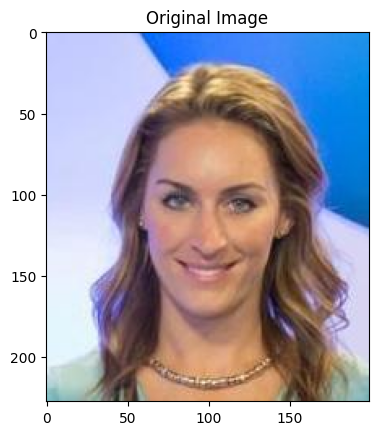

100%|██████████| 10/10 [00:00<00:00, 19.50it/s, start_loss=1.26, end_loss=0.269]


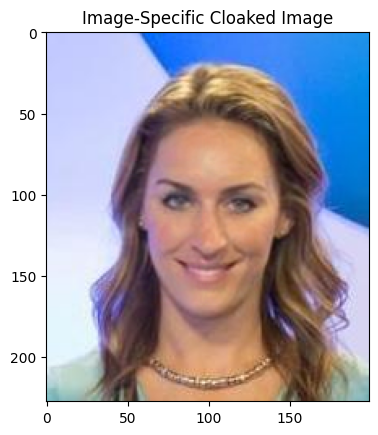

Got back image of shape (228, 199, 3)


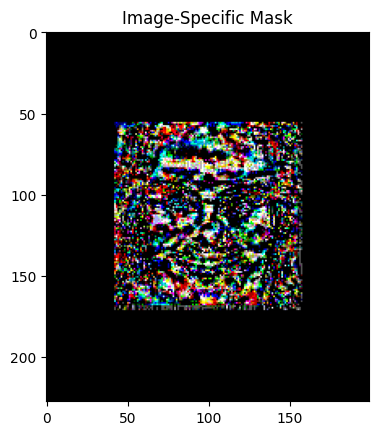



====== Multi-Cloaking ( 1 / 100 : ../data/vggface_tiny_flat/n000432_006404.jpg ) =======


input image has size torch.Size([1, 3, 112, 112])


40it [00:01, 21.68it/s, start_loss=0.114, end_loss=-0.326]                       


Right before saving, range is 0 255
Save dir is: ../data/test/cloaked
Saved image here
====== Full Iteration Took: 23.98475795891136 seconds. =======


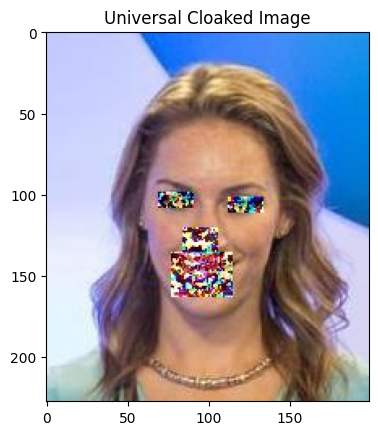

mutli diff range 0 255


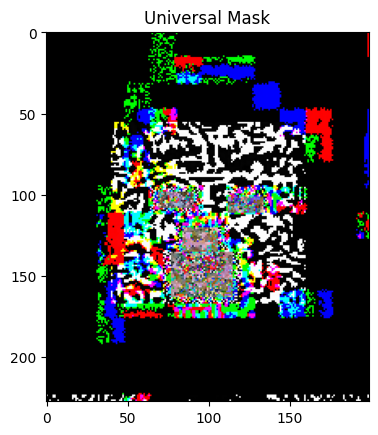

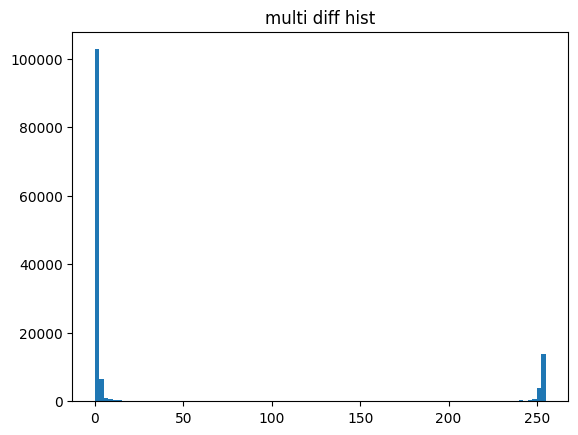

Single SSIM: 0.980087
Single Embedding Distance: 0.943286
Multi SSIM: 0.650060
Multi Embedding Distance: 0.545526


In [2]:
from skimage.metrics import structural_similarity
from insightface_code.recognition.arcface_torch.backbones import get_model
from facenet_pytorch import MTCNN, InceptionResnetV1
import torch.nn.functional as F
%matplotlib inline
%load_ext autoreload
%autoreload 2



IMAGE_PATH = "n000432_006404.jpg"
#IMAGE_PATH = "n000432_005101.jpg"
#IMAGE_PATH = "n000157_055901.jpg"
#IMAGE_PATH = "n000012_022001.jpg"
#IMAGE_PATH = "n000950_001601.jpg"
#IMAGE_PATH = "n000492_028501.jpg"

orig_im = cv2.imread("../data/vggface_tiny_flat/"+IMAGE_PATH)
orig_im = cv2.cvtColor(orig_im, cv2.COLOR_BGR2RGB)
plt.imshow(orig_im)
plt.title("Original Image")
plt.show()

cloaked_im = cloaker.cloak_image("../data/vggface_tiny_flat/"+IMAGE_PATH, pool_size=100)
plt.imshow(cloaked_im)
plt.title("Image-Specific Cloaked Image")
plt.show()

print("Got back image of shape", cloaked_im.shape)

diff = np.abs(orig_im - cloaked_im)
# print("diff min, max are:", np.min(diff), np.max(diff))
# diff = np.clip(diff, a_min=230, a_max=255) 
#plt.set_cmap('Grays')
diff = diff * (diff > 0) * (diff < cloak_function_max_pert * 255.0)
diff = (diff - np.min(diff)) / (np.max(diff) - np.min(diff))
plt.imshow(diff)
plt.title("Image-Specific Mask")
plt.show()

# plt.hist(diff.flatten(), bins=100)
# plt.show()

cloaker.cloak_all_multi(do_paths=["../data/vggface_tiny_flat/"+IMAGE_PATH], save_dir="../data/test/cloaked", gen_save_path="../data/test/gen")

multi_cloaked_im = cv2.imread("../data/test/cloaked/"+IMAGE_PATH[:-4] + ".jpg")
multi_cloaked_im = cv2.cvtColor(multi_cloaked_im, cv2.COLOR_BGR2RGB)
plt.imshow(multi_cloaked_im)
plt.title("Universal Cloaked Image")
plt.show()

multi_diff = np.abs(orig_im - multi_cloaked_im)
#multi_diff = multi_diff * (multi_diff > 0) * (multi_diff < multi_cloak_function_max_pert * 255.0)
#multi_diff = (multi_diff - np.min(multi_diff)) / (np.max(multi_diff) - np.min(multi_diff))
print("mutli diff range", np.min(multi_diff), np.max(multi_diff))
plt.imshow(multi_diff)
plt.title("Universal Mask")
plt.show()

plt.hist(multi_diff.flatten(), bins=100)
plt.title("multi diff hist")
plt.show()


# orig_im_2 = cv2.imread("../data/vggface_tiny_flat/"+IMAGE_PATH_2)
# orig_im_2 = cv2.cvtColor(orig_im_2, cv2.COLOR_BGR2RGB)


def get_embed_dist(im1, im2):
    # Now calculate the embedding distance
    arcface_model = get_model("r100", fp16=False)
    arcface_model.load_state_dict(torch.load("../model_checkpoints/arcface_r100_ms1mv3.pth", map_location=device))
    arcface_model.eval().to(device=device, dtype=torch.float16)
    mtcnn = MTCNN(image_size=cropped_im_size, device=device).to(device)

    # Get the boxes and clean them
    boxes, _ = mtcnn.detect(torch.tensor(im1).to(device))
    # Check for null boxes. If a box is none, replace it with the entire image.
    if type(boxes) == type(None): 
        boxes = [[0, 0, im1.shape[1] - 1, im1.shape[0] - 1]]

    # Make sure that the boxes do not exceed the image size
    for i in range(4):
        boxes[0][i] = int(boxes[0][i]) if boxes[0][i] >= 0.0 else 0
    boxes[0][2] = boxes[0][2] if boxes[0][2] < im1.shape[1] else im1.shape[1] - 1
    boxes[0][3] = boxes[0][3] if boxes[0][3] < im1.shape[0] else im1.shape[0] - 1
    boxes = boxes[0]

    xmin = int(boxes[0])
    ymin = int(boxes[1])
    xmax = int(boxes[2])
    ymax = int(boxes[3])

    im1 = torch.tensor(im1, dtype=torch.float16).to(device).permute(2, 0, 1).squeeze()
    im2 = torch.tensor(im2, dtype=torch.float16).to(device).permute(2, 0, 1).squeeze()

    im1_crop = im1[:, ymin:ymax, xmin:xmax]
    im2_crop = im2[:, ymin:ymax, xmin:xmax]
    
    ssim = structural_similarity(im1_crop.clone().cpu().detach().permute(1, 2, 0).numpy(), im2_crop.clone().cpu().detach().permute(1, 2, 0).numpy(), channel_axis=2, data_range=255.0)

    im1_crop = (im1_crop - 127.5) / 128.0
    im2_crop = (im2_crop - 127.5) / 128.0

    # Now get the embeddings

    im1_crop = F.interpolate(im1_crop.unsqueeze(0), size=(cropped_im_size, cropped_im_size), mode="bilinear", align_corners=False)
    im2_crop = F.interpolate(im2_crop.unsqueeze(0), size=(cropped_im_size, cropped_im_size), mode="bilinear", align_corners=False)
    
    im1_embed = F.normalize(arcface_model(im1_crop).detach().cpu().float(), p=2)
    im2_embed = F.normalize(arcface_model(im2_crop).detach().cpu().float(), p=2)
    
    return ssim, F.cosine_similarity(im1_embed,im2_embed, dim=-1).item()

cloaked_ssim, cloaked_dist = get_embed_dist(orig_im, cloaked_im)
multi_ssim, multi_dist = get_embed_dist(orig_im, multi_cloaked_im)
#second_ssim, second_dist = get_embed_dist(orig_im, orig_im_2)
print(f"Single SSIM: {cloaked_ssim:4f}")
print(f"Single Embedding Distance: {cloaked_dist:4f}")
print(f"Multi SSIM: {multi_ssim:4f}")
print(f"Multi Embedding Distance: {multi_dist:4f}")
#print(f"Reference Embedding Distance: {second_dist:4f}")

# attn_map = cv2.imread("../data/test/attn/map.jpg")
# attn_map = cv2.cvtColor(attn_map, cv2.COLOR_BGR2RGB)
# plt.imshow(attn_map)
# plt.title("AFOG Attention Mask")
# plt.show()




In [1]:
import os
os.environ["OMP_NUM_THREADS"] = "1"        # or a small number like 4
os.environ["OMP_WAIT_POLICY"] = "PASSIVE"  # optional, prevents spin-lock CPU usage
os.environ["ONNX_DISABLE_CPU_AFFINITY"] = "1"
os.environ["ORT_DISABLE_GPU"] = "1"

import onnxruntime as ort
ort.set_default_logger_severity(4)  # 0=verbose, 1=info, 2=warning, 3=error, 4=fatal


from arc2face.Arc2Face.arc2face import CLIPTextModelWrapper, project_face_embs
import torch
import cv2
import matplotlib.pyplot as plt
import sys
import os
import time
import gc
import numpy as np
%matplotlib inline
%load_ext autoreload
%autoreload 2

from diffusers import (
    StableDiffusionPipeline,
    UNet2DConditionModel,
    DPMSolverMultistepScheduler,
)

# Arc2Face is built upon SD1.5
# The repo below can be used instead of the now deprecated 'runwayml/stable-diffusion-v1-5'
base_model = 'stable-diffusion-v1-5/stable-diffusion-v1-5'

encoder = CLIPTextModelWrapper.from_pretrained(
    "arc2face/encoder", torch_dtype=torch.float16
)

unet = UNet2DConditionModel.from_pretrained(
    "arc2face/Arc2Face", torch_dtype=torch.float16
)


pipeline = StableDiffusionPipeline.from_pretrained(
        base_model,
        text_encoder=encoder,
        unet=unet,
        torch_dtype=torch.float16,
        safety_checker=None,
    )

pipeline.scheduler = DPMSolverMultistepScheduler.from_config(pipeline.scheduler.config)
pipeline = pipeline.to('cuda')

@torch.no_grad()
def _make_negative_embeds(pipe, batch_size, like_embed):
    """
    Create negative (unconditional) prompt embeds that match shape/dtype/device
    of Arc2Face prompt embeds. Uses the Arc2Face text encoder on "".
    Falls back to zeros if tokenizer/encoder aren't available.
    """
    try:
        tok = pipe.tokenizer(
            [""] * batch_size,
            return_tensors="pt",
            padding="max_length",
            max_length=pipe.tokenizer.model_max_length
        ).to(like_embed.device)
        # Arc2Face CLIPTextModelWrapper returns (hidden_states, ...) so take [0]
        neg = pipe.text_encoder(tok.input_ids)[0]
        # Make sure dtype matches UNet (usually fp16)
        neg = neg.to(dtype=like_embed.dtype)
    except Exception:
        neg = torch.zeros_like(like_embed)
    return neg


def pipeline_forward_with_grad(
    pipe,
    prompt_embeds,                 # [B, T, C] from project_face_embs(...), requires_grad=True
    num_inference_steps=25,
    guidance_scale=7.5,
    height=512,
    width=512,
    generator=None,
    latents=None,
    negative_prompt_embeds=None,   # optional [B, T, C]; if None we build one
):
    device = pipe._execution_device
    dtype  = pipe.unet.dtype
    bsz    = prompt_embeds.shape[0]

    # Build negative embeds if not provided (match shape/dtype/device)
    if negative_prompt_embeds is None:
        negative_prompt_embeds = _make_negative_embeds(pipe, bsz, prompt_embeds)

    # Scheduler
    pipe.scheduler.set_timesteps(num_inference_steps, device=device)
    timesteps = pipe.scheduler.timesteps

    # Latent init
    if latents is None:
        latents = torch.randn(
            (bsz, pipe.unet.in_channels, height // 8, width // 8),
            generator=generator, device=device, dtype=dtype
        )
    # Match HF pipeline: scale init noise
    latents = latents * pipe.scheduler.init_noise_sigma

    # Denoising loop (single UNet call per step with concatenation for CFG)
    for t in timesteps:
        # Some schedulers require scaling the input latents each step
        latent_model_input = pipe.scheduler.scale_model_input(latents, t)

        # Concatenate unconditional + conditional for a single forward
        latent_in   = torch.cat([latent_model_input, latent_model_input], dim=0)
        embeds_in   = torch.cat([negative_prompt_embeds, prompt_embeds], dim=0)

        # One UNet call
        noise_pred  = pipe.unet(latent_in, t, encoder_hidden_states=embeds_in).sample

        # Split and apply CFG
        noise_uncond, noise_text = noise_pred.chunk(2, dim=0)
        noise_pred = noise_uncond + guidance_scale * (noise_text - noise_uncond)

        # Scheduler step
        latents = pipe.scheduler.step(noise_pred, t, latents).prev_sample

    # Decode (match HF: divide BEFORE decode)
    image_pt = pipe.vae.decode(
        latents / getattr(pipe.vae.config, "scaling_factor", 0.18215),
        return_dict=False
    )[0]

    # Rescale to [0,1]
    image_pt = (image_pt / 2 + 0.5).clamp(0, 1)

    # Detach only for visualization/output
    image_pil = pipe.image_processor.postprocess(image_pt.detach(), output_type="pt")[0]

    # Cleanup to prevent Jupyter re-run OOMs
    del noise_pred, noise_uncond, noise_text, latent_in, embeds_in, latent_model_input
    gc.collect()
    torch.cuda.empty_cache()

    return image_pt, image_pil.cpu().float().detach().numpy().transpose((1, 2, 0))

/home/hice1/zyahn3/.conda/envs/Face/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2025-10-22 22:16:42.451368: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-10-22 22:16:42.586914: I tensorflow/core/util/util.cc:169] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-10-22 22:16:42.618615

Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: ./arc2face/models/antelopev2/1k3d68.onnx landmark_3d_68 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: ./arc2face/models/antelopev2/2d106det.onnx landmark_2d_106 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: ./arc2face/models/antelopev2/arcface.onnx recognition ['None', 3, 112, 112] 127.5 127.5
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: ./arc2face/models/antelopev2/genderage.onnx genderage ['None', 3, 96, 96] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: ./arc2face/models/antelopev2/scrfd_10g_bnkps.onnx detection [1, 3, '?', '?'] 127.5 128.0
set det-size: (640, 640)
Loaded image: (112, 112, 3)
Resized face:

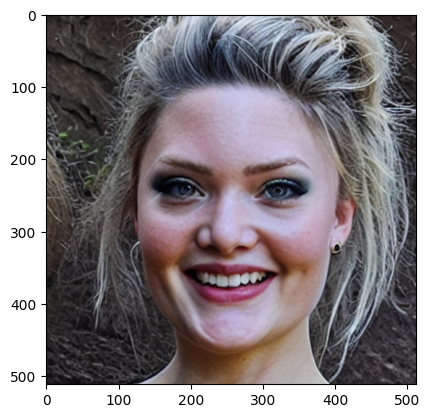

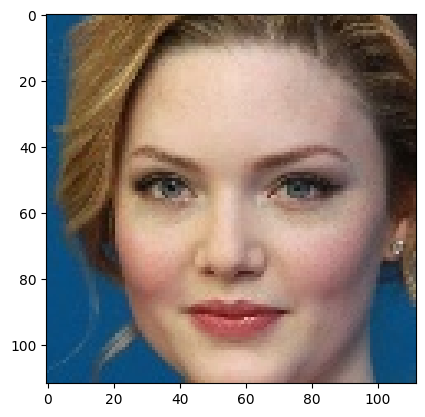

In [15]:
import sys, os
stderr = sys.stderr
sys.stderr = open(os.devnull, 'w')
import time

#IMAGE_PATH = "../data/vggface_small_flat/n000454_008201.jpg"
#IMAGE_PATH = "../data/pubfig_small_flat/AdamSandler_38.jpg"
IMAGE_PATH = "../data/privacy_common/probe/357967_0.jpg"

so = ort.SessionOptions()
so.execution_mode = ort.ExecutionMode.ORT_SEQUENTIAL  # optional, forces single-thread
so.intra_op_num_threads = 1
so.inter_op_num_threads = 1
# This flag prevents ORT from messing with thread affinity
so.add_session_config_entry("session.set_denormal_as_zero", "1")
so.add_session_config_entry("session.disable_prepacking", "1")

from insightface.app import FaceAnalysis
from PIL import Image
# --- Init FaceAnalysis with antelopev2 ---
app = FaceAnalysis(
    name='antelopev2',
    root='./arc2face',
    providers=['CUDAExecutionProvider', 'CPUExecutionProvider']
)
app.prepare(ctx_id=0, det_size=(640, 640), det_thresh=0.5)

# --- Load the image ---
img = cv2.imread(IMAGE_PATH)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
orig_img = img.copy()
print("Loaded image:", img.shape)
plt.imshow(img)

# --- Resize to 112x112 (ArcFace expected size) ---
face_img = cv2.resize(img, (112, 112))  # width, height
print("Resized face:", face_img.shape)  # (112, 112, 3)

# --- Get embedding directly from ArcFace ---
arcface_model = app.models['recognition']

# ✅ This is the correct way — pass raw RGB face, not preprocessed
id_emb = torch.tensor(arcface_model.get_feat(face_img), dtype=torch.float16).cuda()
# get the arcface embedding
#faces = app.get(img)
#faces = sorted(faces, key=lambda x:(x['bbox'][2]-x['bbox'][0])*(x['bbox'][3]-x['bbox'][1]))[-1]  # select largest face (if more than one detected)
#id_emb = torch.tensor(faces['embedding'], dtype=torch.float16)[None].cuda()



print("FaceAnalysis embedding has range", torch.min(id_emb), torch.max(id_emb))
id_emb = id_emb/torch.norm(id_emb, dim=1, keepdim=True)   # normalize embedding
print("FaceAnalysis embedding post-norm has range", torch.min(id_emb), torch.max(id_emb))
# project to the pipeline and ask for gradients

id_emb = project_face_embs(pipeline, id_emb).detach().clone()   # ensure no history
id_emb.requires_grad_(True)
print("Range of embeds:", torch.min(id_emb), torch.max(id_emb))

# UNCOMMENT IF WE DON'T CARE ABOUT GRADIENTS
# num_images=4
# start = time.perf_counter()
# images = pipeline(prompt_embeds=id_emb, num_inference_steps=25, guidance_scale=3.0, num_images_per_prompt=num_images, output_type="pt").images
# end = time.perf_counter()
# print(f"Generating {num_images} took {end-start} seconds")

NUM_ITERS = 5
optimizer = torch.optim.AdamW([id_emb], lr=0.001)

#for _ in range(NUM_ITERS):
images, pil_images = pipeline_forward_with_grad(
    pipeline,
    prompt_embeds=id_emb,
    num_inference_steps=25,
    guidance_scale=3.0,
    height=512,
    width=512,
)

#print(pil_images)
    
plt.imshow(2.0*(pil_images-0.5))
plt.show()

plt.imshow(orig_img)
#     optimizer.zero_grad()
#     optimizer = torch.optim.AdamW([id_emb], lr=0.1)

#     loss = torch.sum(images[0])
#     loss.backward()

#     old_id_emb = id_emb.clone()

#     optimizer.step()
#     old_id_emb[:, 4, :] = id_emb[:, 4, :]
#     id_emb = old_id_emb.clone().detach()

In [ ]:
print(len(images))
# im0 = images[0].detach().cpu().float().numpy().transpose((1, 2, 0))
# plt.imshow(im0)
# plt.show()

optimizer.zero_grad()
optimizer = torch.optim.AdamW([id_emb], lr=0.001)

print("id emb is", id_emb)
loss = torch.sum(images[0])
loss.backward()
print("id_emb grad is", id_emb.grad)

def grad_hook(grad):
    return grad * mask

old_id_emb = id_emb.clone()

optimizer.step()
old_id_emb[:, 4, :] = id_emb[:, 4, :]
id_emb = old_id_emb.clone().detach()
print("id emb is", id_emb)